In [2]:
# loads numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [4]:
import torch # WE WILL BE USING PYTORCH THIS TIME, 
             # IT IS MORE ADVANCED THAN KERAS BUT EXTREMELY POPULAR!
             # MOST OF THE CODE HERE IS READY TO GO JUST TRY TO UNDERSTAND IT!

In [5]:
#
# CHECK IF THE GPU IS AVAILABLE ON CHIMERA21
#
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print('GPU not available, using CPU!')

NVIDIA A100-SXM4-40GB


## 1. Data Processing. (10 points)

In [ ]:
### DOWNLOAD THE DATA
!wget https://cs666.org/data/mito.npz

In [6]:
# The data includes images and manually segmented masks.
import numpy as np
loaded = np.load('mito.npz')
images = loaded['arr_0'][0]
masks = loaded['arr_0'][1]

In [7]:
# PROCESS THE IMAGES
images = (images - images.min()) / (images.max() - images.min())
masks = masks.astype(bool).astype(float)

In [6]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

1. ```images = (images - images.min()) ...```: This performs Min-Max Normalization. It scales the raw pixel intensities of the images down to a strict range between 0.0 and 1.0. This is crucial for training neural networks because large pixel values (like 0-255) can cause gradients to explode and make training unstable.
2. ```masks = masks.astype(bool).astype(float)```: This makes the ground-truth segmentation masks are strictly binary arrays of floats (0.0 for background, 1.0 for mitochondria).

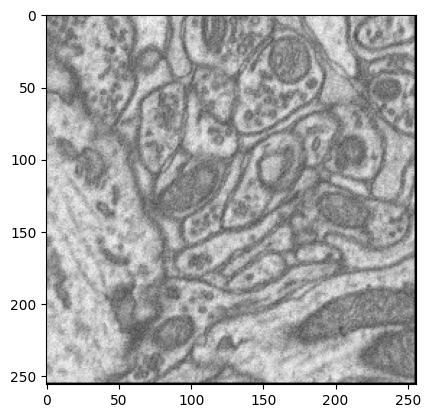

In [8]:
import matplotlib.pyplot as plt
plt.imshow(images[0], cmap='gray')

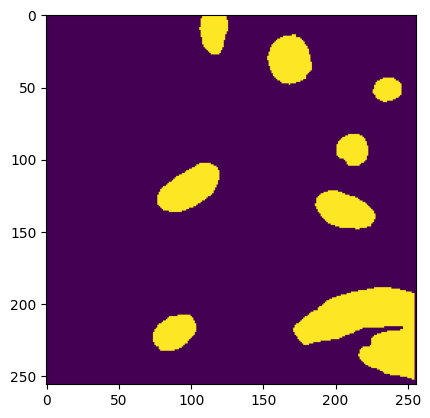

In [9]:
plt.imshow(masks[0])

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, masks, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [ ]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

This code splits the dataset into three distinct parts:

Training Set (```X_train```): 70% of the data used to actually train and update the model's weights.

Validation Set (```X_val```): 15% of the data used to evaluate the model during training to track progress, tune parameters, and save the best epoch without overfitting.

Testing Set (```X_test```): The final 15% of the data kept completely unseen until the very end to give an unbiased evaluation of the model's real-world performance.

## 2. Make the Data Pytorch-ready! (10 points)

In [12]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [13]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([])

In [ ]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

This sets up Data Augmentation for the training data. During training, it randomly applies horizontal flips, vertical flips, and 90-degree rotations (each with a 50% chance). This artificially increases the size and diversity of the training dataset, helping to prevent the U-Net from overfitting to specific orientations of mitochondria. The validation set is intentionally left empty (```A.Compose([])```) because we want to evaluate the model on true, unaltered images.

In [14]:
class MitoDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # add channel dimension: (H, W) -> (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [15]:
train_dataset = MitoDataset(X_train, y_train, transform=train_transform)
val_dataset = MitoDataset(X_val, y_val, transform=val_transform)
test_dataset = MitoDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [ ]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

```MitoDataset```: Wraps the numpy arrays and transforms into PyTorch Dataset objects, so custom Dataset class (```MitoDataset```) can fetch a single image and apply the augmentations on the fly.

```DataLoader```: Wraps the datasets to automate the feeding process during training. It batches the data (16 images at a time), shuffles the training data so the network doesn't memorize the order, and uses multiprocessing (```num_workers=2```) to quickly load the data onto the GPU without bottlenecking the training loop. ```batch_size``` defines how many mini-batches are to be processed and we don't apply shuffle to validation and test to keep the original data for evaluation.

## 3. Configure the Classifier! (30 points)

In [17]:
#
# SETUP U-NET
#
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

In [18]:
# DICE LOSS FUNCTION
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [19]:
# DICE METRIC
def dice_score(pred, target, threshold=0.5, eps=1e-7):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

In [20]:
# SINGLE EPOCH, PYTORCH IS A BIT MORE COMPLEX HERE..
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images_batch, masks_batch in loader:
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        with torch.set_grad_enabled(training):
            preds = model(images_batch)
            loss = loss_fn(preds, masks_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks_batch)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

## 4. Train the U-Net! (20 points)

In [21]:
#
# TRAINING LOOP
#
num_epochs = 10

train_losses, val_losses = [], []
train_dices, val_dices = [], []

best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice:", best_val_dice)

Epoch 1/10 | train_loss=0.4516, train_dice=0.6121 | val_loss=0.6111, val_dice=0.0024
Epoch 2/10 | train_loss=0.1915, train_dice=0.8245 | val_loss=0.1687, val_dice=0.7989
Epoch 3/10 | train_loss=0.1138, train_dice=0.8674 | val_loss=0.1349, val_dice=0.8238
Epoch 4/10 | train_loss=0.0887, train_dice=0.8879 | val_loss=0.0672, val_dice=0.9200
Epoch 5/10 | train_loss=0.0734, train_dice=0.9035 | val_loss=0.0763, val_dice=0.8977
Epoch 6/10 | train_loss=0.0608, train_dice=0.9214 | val_loss=0.0532, val_dice=0.9318
Epoch 7/10 | train_loss=0.0530, train_dice=0.9317 | val_loss=0.0571, val_dice=0.9240
Epoch 8/10 | train_loss=0.0581, train_dice=0.9235 | val_loss=0.0588, val_dice=0.9174
Epoch 9/10 | train_loss=0.0501, train_dice=0.9324 | val_loss=0.0441, val_dice=0.9420
Epoch 10/10 | train_loss=0.0480, train_dice=0.9350 | val_loss=0.0515, val_dice=0.9281
Best val dice: 0.9419919848442078


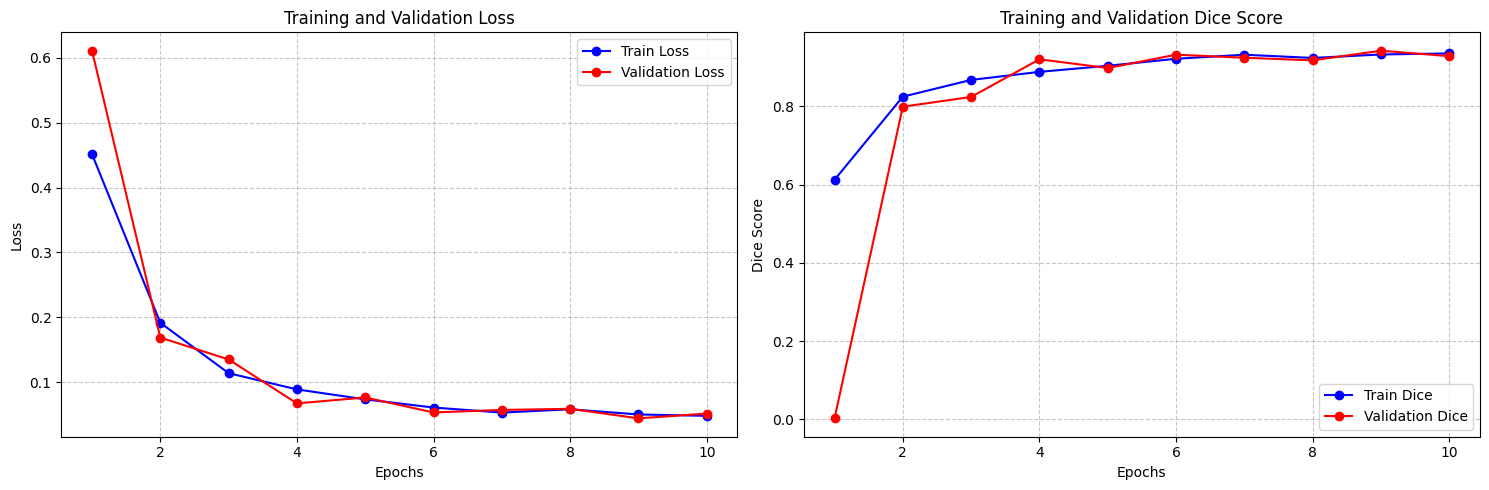

In [22]:
# TODO: Plot the loss and dice curves!
# TODO: YOUR CODE
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss Curve
ax1.plot(epochs, train_losses, label='Train Loss', color='blue', marker='o')
ax1.plot(epochs, val_losses, label='Validation Loss', color='red', marker='o')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot Dice Curve
ax2.plot(epochs, train_dices, label='Train Dice', color='blue', marker='o')
ax2.plot(epochs, val_dices, label='Validation Dice', color='red', marker='o')
ax2.set_title('Training and Validation Dice Score')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Dice Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Do these plots look good?
# TODO: YOUR ANSWER

#### A healthy training process is shown as the Training and Validation Loss curves steadily decrease and stabilize, while the Training and Validation Dice scores steadily increase toward 1.0. If the validation loss had suddenly spiked upward while training loss went down, it would indicate severe overfitting, but the curves track each other closely here.

## 5. Testing the U-Net. (20 points)

In [23]:
# EVALUATE THE MODEL ON THE TEST DATA
model.load_state_dict(torch.load("best_mito_model.pth", map_location=device))
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

/tmp/ipykernel_1383362/102787313.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_mito_model.pth", map_location=device))


Test loss: 0.0426
Test dice: 0.9435


In [ ]:
# Scores are good but let's do some Detective Work to see if
# the classifier actually works well!

# RUN PREDICTIONS
model.eval()

images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds = model(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

images_batch = images_batch.cpu().numpy()
masks_batch = masks_batch.numpy()
preds = preds.cpu().numpy()

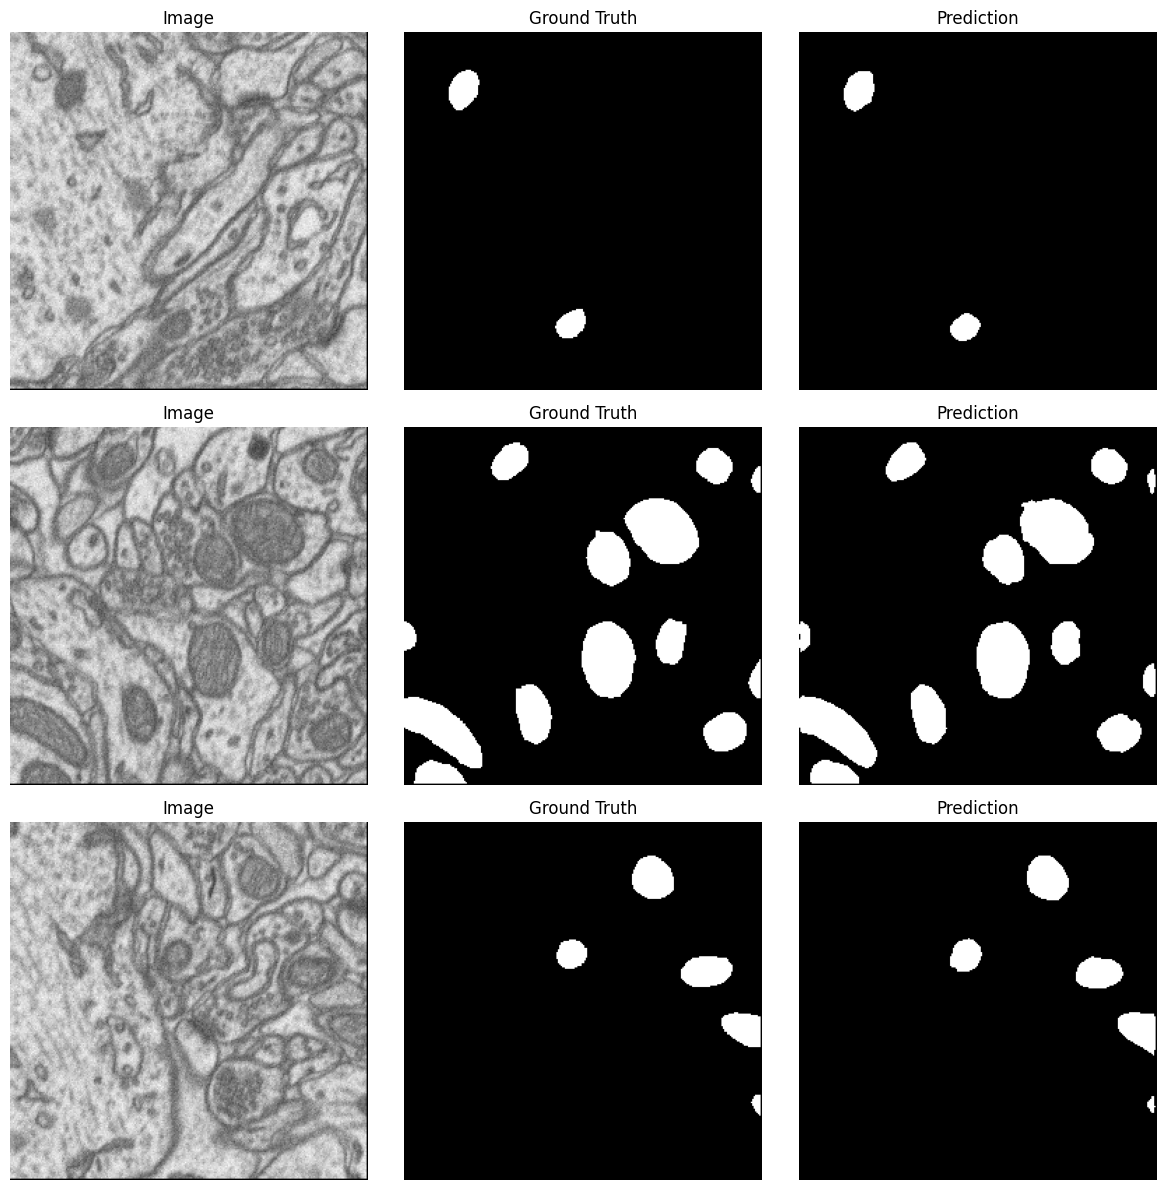

In [ ]:
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Interpretation. (10 points)

In [ ]:
# TODO: Do you think the classifier works well?
# TODO: YOUR ANSWER

#### Yes, the classifier works well. The quantitative 94.35% Test Dice score and very low test loss well-reflects the high-quality results. Most of the segmentations overlaps with the ground truth masks, capturing the fine-grained boundaries of the mitochondria while successfully ignoring the complex cellular background noise.

## Bonus: Improve the results. (33 points)

In [ ]:
# Try to get better performance and show an improved Dice score on the test set!
# TODO: YOUR CODE!

In [ ]:
import albumentations as A

bonus_train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.3)
])

bonus_train_dataset = MitoDataset(X_train, y_train, transform=bonus_train_transform)
bonus_train_loader = DataLoader(bonus_train_dataset, batch_size=16, shuffle=True, num_workers=2)

# We use resnet34 for a slightly deeper network, and ImageNet weights to start with pre-trained features
bonus_model = smp.Unet(
    encoder_name="resnet34",      
    encoder_weights="imagenet",   
    in_channels=1,
    classes=1
).to(device)

# L2 Regularization (Weight Decay)
# AdamW implements weight decay better than standard Adam
bonus_optimizer = torch.optim.AdamW(bonus_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Reduces the learning rate by half if the validation dice score doesn't improve for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(bonus_optimizer, mode='max', patience=3, factor=0.5)

num_epochs = 30
best_bonus_val_dice = 0.0

print("Starting Bonus Training Pipeline...")
for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(bonus_model, bonus_train_loader, optimizer=bonus_optimizer)
    val_loss, val_dice = run_epoch(bonus_model, val_loader, optimizer=None)
    
    scheduler.step(val_dice)

    if val_dice > best_bonus_val_dice:
        best_bonus_val_dice = val_dice
        torch.save(bonus_model.state_dict(), "best_bonus_mito_model.pth")

    print(f"Epoch {epoch+1}/{num_epochs} | train_dice={train_dice:.4f} | val_loss={val_loss:.4f}, val_dice={val_dice:.4f}")



Starting Bonus Training Pipeline...


Epoch 1/30 | train_dice=0.4177 | val_loss=0.4266, val_dice=0.6775
Epoch 2/30 | train_dice=0.5018 | val_loss=0.2618, val_dice=0.6540
Epoch 3/30 | train_dice=0.5044 | val_loss=0.1196, val_dice=0.8542
Epoch 4/30 | train_dice=0.5217 | val_loss=0.1086, val_dice=0.8659
Epoch 5/30 | train_dice=0.5478 | val_loss=0.0978, val_dice=0.8980
Epoch 6/30 | train_dice=0.5491 | val_loss=0.1508, val_dice=0.8488
Epoch 7/30 | train_dice=0.5528 | val_loss=0.0697, val_dice=0.9156
Epoch 8/30 | train_dice=0.5283 | val_loss=0.0656, val_dice=0.9160
Epoch 9/30 | train_dice=0.5379 | val_loss=0.0755, val_dice=0.9167
Epoch 10/30 | train_dice=0.5460 | val_loss=0.0693, val_dice=0.9146
Epoch 11/30 | train_dice=0.5505 | val_loss=0.0811, val_dice=0.9027
Epoch 12/30 | train_dice=0.5551 | val_loss=0.0510, val_dice=0.9343
Epoch 13/30 | train_dice=0.5623 | val_loss=0.0481, val_dice=0.9331
Epoch 14/30 | train_dice=0.5728 | val_loss=0.0479, val_dice=0.9362
Epoch 15/30 | train_dice=0.5892 | val_loss=0.0549, val_dice=0.9300
Epoc

In [ ]:
bonus_model.load_state_dict(torch.load("best_bonus_mito_model.pth", map_location=device))
test_loss, test_dice = run_epoch(bonus_model, test_loader, optimizer=None)

print("\n--- Bonus Model Results ---")
print("Bonus Test Loss:", round(test_loss, 4))
print("Bonus Test Dice:", round(test_dice, 4))

/tmp/ipykernel_1383362/2846878511.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bonus_model.load_state_dict(torch.load("best_bonus_mito_model.pth", map_location=device


--- Bonus Model Results ---
Bonus Test Loss: 0.0339
Bonus Test Dice: 0.9513


### The performance boost resulted from adopting a pre-trained ResNet34 encoder, which utilizes robust features learned from large-scale datasets. Advanced data augmentation through spatial shifts and brightness adjustments compelled the model to recognize general mitochondria morphology rather than over-fitting to specific image orientations.  Additionally, implementing an AdamW optimizer with a dynamic learning rate scheduler ensured the model stabilized at a superior local minimum during final training phases.

In [ ]:
#
# You made it!!
#
#                 _ ___                /^^\ /^\  /^^\_
#     _          _@)@) \            ,,/ '` ~ `'~~ ', `\.
#   _/o\_ _ _ _/~`.`...'~\        ./~~..,'`','',.,' '  ~:
#  / `,'.~,~.~  .   , . , ~|,   ,/ .,' , ,. .. ,,.   `,  ~\_
# ( ' _' _ '_` _  '  .    , `\_/ .' ..' '  `  `   `..  `,   \_
#  ~V~ V~ V~ V~ ~\ `   ' .  '    , ' .,.,''`.,.''`.,.``. ',   \_
#   _/\ /\ /\ /\_/, . ' ,   `_/~\_ .' .,. ,, , _/~\_ `. `. '.,  \_
#  < ~ ~ '~`'~'`, .,  .   `_: ::: \_ '      `_/ ::: \_ `.,' . ',  \_
#   \ ' `_  '`_    _    ',/ _::_::_ \ _    _/ _::_::_ \   `.,'.,`., \-,-,-,_,_,
#    `'~~ `'~~ `'~~ `'~~  \(_)(_)(_)/  `~~' \(_)(_)(_)/ ~'`\_.._,._,'_;_;_;_;_;
#